<a href="https://colab.research.google.com/github/eliam22/Modelos/blob/main/kmeans.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


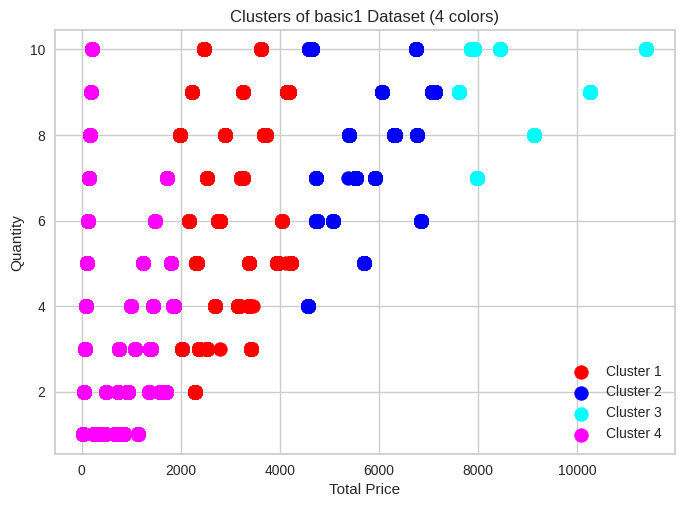

,Customer ID,Age,Gender,Loyalty Member,Product Type,SKU,Rating,Order Status,Payment Method,Total Price,Unit Price,Quantity,Purchase Date,Shipping Type,Add-ons Purchased,Add-on Total,Cluster
0,1000,53,Male,No,Smartphone,SKU1004,2,Cancelled,Credit Card,5538.33,791.19,7,2024-03-20,Standard,"Accessory,Accessory,Accessory",40.21,1
1,1000,53,Male,No,Tablet,SKU1002,3,Completed,Paypal,741.09,247.03,3,2024-04-20,Overnight,Impulse Item,26.09,3
2,1002,41,Male,No,Laptop,SKU1005,3,Completed,Credit Card,1855.84,463.96,4,2023-10-17,Express,NaN,0.00,3
3,1002,41,Male,Yes,Smartphone,SKU1004,2,Completed,Cash,3164.76,791.19,4,2024-08-09,Overnight,"Impulse Item,Impulse Item",60.16,0
4,1003,75,Male,Yes,Smartphone,SKU1001,5,Completed,Cash,41.50,20.75,2,2024-05-21,Express,Accessory,35.56,3


In [132]:
from google.colab import drive
drive.mount("/content/drive/")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

# Function to Visualize the Clusters
def visualize_clusters(dataset, x_col, y_col, c_num, colors, name):
    # Visualizando los clusters
    for i in range(c_num):
        plt.scatter(dataset[dataset['Cluster'] == i][x_col],
                    dataset[dataset['Cluster'] == i][y_col], s=100,
                    c=colors[i], label=f'Cluster {i + 1}')

    plt.title(f'Clusters of {name} Dataset ({c_num} colors)')
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.legend()
    plt.show()

# Cargar el dataset
basic1 = pd.read_csv('/content/drive/MyDrive/DataSets/kmeans/Electronic_sales_Sep2023-Sep2024.csv')

# Preprocesar el conjunto de datos
basic_1_1 = basic1.copy()
basic_1_1.drop(['Customer ID', 'Gender', 'Payment Method', 'Purchase Date', 'Shipping Type', 'Add-ons Purchased'], axis=1, inplace=True)

# Codificar las columnas categóricas
basic_1_1_encoded = pd.get_dummies(basic_1_1, drop_first=True)

# Aplicar KMeans
kmeans_basic1 = KMeans(n_clusters=4, init='k-means++', random_state=42, n_init='auto')
y_kmeans_basic1 = kmeans_basic1.fit_predict(basic_1_1_encoded)

# Agregar la columna de cluster al DataFrame original
basic1['Cluster'] = y_kmeans_basic1

# Visualizar los clusters usando 'Total Price' y 'Quantity' como ejes
visualize_clusters(basic1, 'Total Price', 'Quantity', 4, ['red', 'blue', 'cyan', 'magenta'], 'basic1')

# Mostrar el DataFrame con la columna de cluster
basic1.head()


In [133]:
basic_1_1['Age'].unique()


array([53, 41, 75, 25, 24, 35, 66, 72, 42, 73, 22, 61, 34, 45, 57, 71, 76,
       49, 77, 79, 69, 20, 54, 32, 60, 56, 65, 67, 50, 30, 21, 37, 62, 64,
       44, 27, 46, 58, 26, 55, 74, 31, 19, 68, 63, 33, 40, 80, 36, 18, 23,
       70, 29, 78, 52, 43, 47, 48, 38, 39, 59, 51, 28])

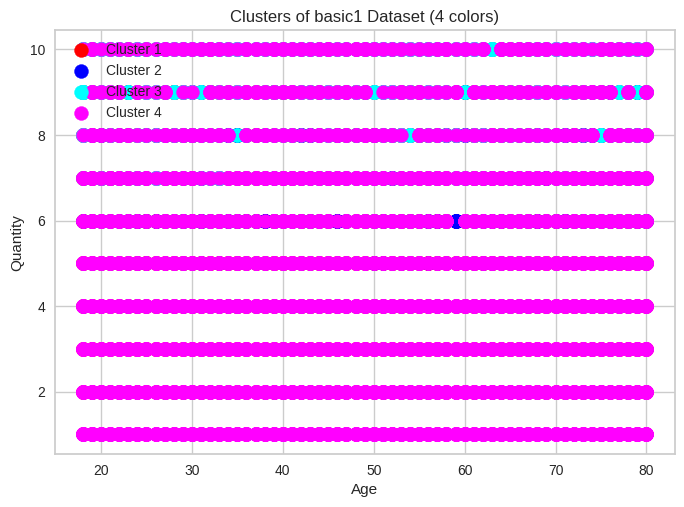

In [134]:
visualize_clusters(basic1, 'Age', 'Quantity', 4, ['red', 'blue', 'cyan', 'magenta'], 'basic1')


Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).
   Age  Rating  Total Price  Unit Price  Quantity  Add-on Total  \
0   53       2      5538.33      791.19         7         40.21   
1   53       3       741.09      247.03         3         26.09   
2   41       3      1855.84      463.96         4          0.00   
3   41       2      3164.76      791.19         4         60.16   
4   75       5        41.50       20.75         2         35.56   

   Loyalty Member_Yes  Product Type_Laptop  Product Type_Smartphone  \
0               False                False                     True   
1               False                False                    False   
2               False                 True                    False   
3                True                False                     True   
4                True                False                     True   

   Product Type_Smartwatch  ...  SKU_LT

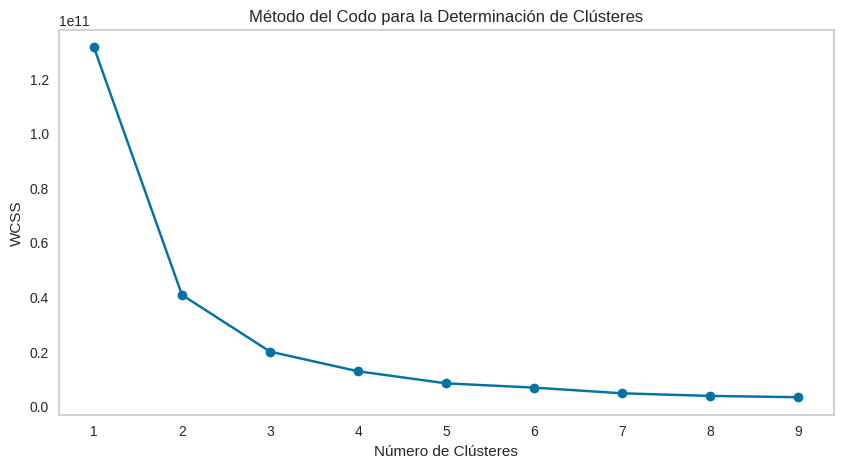

In [135]:
from google.colab import drive
drive.mount("/content/drive/")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

# Cargar el dataset
basic1 = pd.read_csv('/content/drive/MyDrive/DataSets/kmeans/Electronic_sales_Sep2023-Sep2024.csv')

# Hacer una copia del DataFrame
basic1_1 = basic1.copy()

# Eliminar columnas que no son numéricas
basic1_1.drop(['Customer ID', 'Gender', 'Payment Method', 'Purchase Date', 'Shipping Type', 'Add-ons Purchased'], axis=1, inplace=True)

# Codificar columnas categóricas si hay alguna
basic1_1_encoded = pd.get_dummies(basic1_1, drop_first=True)

# Comprobar las primeras filas del DataFrame codificado
print(basic1_1_encoded.head())

# Crear la lista para almacenar el WCSS
wcss = []

# Calcular WCSS para diferentes números de clústeres
for i in range(1, 10):
    kmeans = KMeans(n_clusters=i, max_iter=300, init='k-means++', random_state=42, n_init='auto')
    kmeans.fit(basic1_1_encoded)  # Asegúrate de usar el DataFrame codificado
    wcss.append(kmeans.inertia_)

# Visualizar el gráfico del codo
plt.figure(figsize=(10, 5))
plt.plot(range(1, 10), wcss, marker='o')
plt.title('Método del Codo para la Determinación de Clústeres')
plt.xlabel('Número de Clústeres')
plt.ylabel('WCSS')
plt.xticks(range(1, 10))  # Configurar ticks para el eje x
plt.grid()
plt.show()


   Age  Rating  Total Price  Unit Price  Quantity  Add-on Total  \
0   53       2      5538.33      791.19         7         40.21   
1   53       3       741.09      247.03         3         26.09   
2   41       3      1855.84      463.96         4          0.00   
3   41       2      3164.76      791.19         4         60.16   
4   75       5        41.50       20.75         2         35.56   

   Loyalty Member_Yes  Product Type_Laptop  Product Type_Smartphone  \
0               False                False                     True   
1               False                False                    False   
2               False                 True                    False   
3                True                False                     True   
4                True                False                     True   

   Product Type_Smartwatch  ...  SKU_LTP123  SKU_SKU1001  SKU_SKU1002  \
0                    False  ...       False        False        False   
1                    Fal

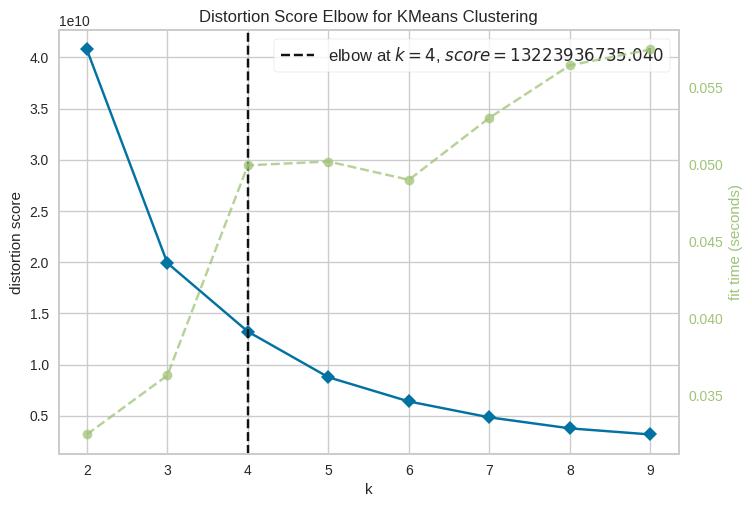

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [136]:
# Hacer una copia del DataFrame
basic1_1 = basic1.copy()

# Eliminar columnas no numéricas
basic1_1.drop(['Customer ID', 'Gender', 'Payment Method', 'Purchase Date', 'Shipping Type', 'Add-ons Purchased'], axis=1, inplace=True)

# Codificar columnas categóricas si hay alguna
basic1_1_encoded = pd.get_dummies(basic1_1, drop_first=True)

# Comprobar las primeras filas del DataFrame codificado
print(basic1_1_encoded.head())

# Aplicar KElbowVisualizer
model = KMeans(random_state=4)
visualizer = KElbowVisualizer(model, k=(2, 10))

# Ajustar el visualizador a los datos
visualizer.fit(basic1_1_encoded)  # Asegúrate de usar el DataFrame codificado
visualizer.show()